In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import os

WD =  os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(WD, "..", ".."))
RESULTS = os.path.join(BASE_DIR, "data", "results", "abbadingo", "abbadingo_test_results.csv")

df = pd.read_csv(RESULTS)

cols = [
    "build_time_us",
    "query_time_us",
    "memory_bytes"
]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["is_timeout"] = df["build_time_us"].isna()

In [134]:
clean = df[df["is_timeout"] == False].copy()

clean["build_time_us"] = clean["build_time_us"] / 1000
clean["query_time_us"] = clean["query_time_us"] / 1000
clean["memory_bytes"] = clean["memory_bytes"] / (1024 * 1024)

clean = clean.rename(columns={
    "build_time_us": "build_time_ms",
    "query_time_us": "query_time_ms",
    "memory_bytes": "memory_mib"
})

clean

,dataset,status,impl,positive_set_size,negative_set_size,number_of_queries,build_time_ms,query_time_ms,memory_mib,total_output_len,is_timeout
0,trainA,OK,naive,2433.0,2023.0,65350.0,1.070,56.024,0.555634,626646.0,False
1,trainA,OK,precomp,2433.0,2023.0,65350.0,3071.621,12.295,289.099834,581192.0,False
2,trainA,OK,sqrt,2433.0,2023.0,65350.0,55.927,17.896,12.493469,644221.0,False
3,trainA,OK,naive,2433.0,2023.0,65350.0,1.724,63.543,0.555634,626646.0,False
4,trainA,OK,precomp,2433.0,2023.0,65350.0,3138.269,9.314,289.099834,581192.0,False
...,...,...,...,...,...,...,...,...,...,...,...
233,trainT,OK,sqrt,15754.0,16746.0,39261.0,1010.459,72.940,146.256351,527622.0,False
234,trainT,OK,naive,15754.0,16746.0,39261.0,15.488,350.595,6.328796,528966.0,False
236,trainT,OK,sqrt,15754.0,16746.0,39261.0,911.032,79.789,146.256351,527622.0,False
237,trainT,OK,naive,15754.0,16746.0,39261.0,14.900,356.792,6.328796,528966.0,False


In [135]:
summary = (
    clean.groupby(["dataset", "impl"])
        .agg(
            build_mean_ms=("build_time_ms", "mean"),
            build_std_ms=("build_time_ms", "std"),
            query_mean_ms=("query_time_ms", "mean"),
            query_std_ms=("query_time_ms", "std"),
            memory_mib=("memory_mib", "mean"),
            num_pos=("positive_set_size", "first"),
            num_neg=("negative_set_size", "first"),
            num_queries=("number_of_queries", "first"),
        )
        .reset_index()
)

summary["total_mean_ms"] = (
    summary["build_mean_ms"] +
    summary["query_mean_ms"]
)

summary["query_ms_per_query"] = (
    summary["query_mean_ms"] /
    summary["num_queries"]
)

summary["num_traces"] = (
    summary["num_pos"] +
    summary["num_neg"]
)


summary

,dataset,impl,build_mean_ms,build_std_ms,query_mean_ms,query_std_ms,memory_mib,num_pos,num_neg,num_queries,total_mean_ms,query_ms_per_query,num_traces
0,train.1,naive,0.9918,0.047678,77.2936,2.262453,0.555634,2020.0,1458.0,59968.0,78.2854,0.001289,3478.0
1,train.1,precomp,1621.3808,73.475671,9.9330,0.494096,164.371422,2020.0,1458.0,59968.0,1631.3138,0.000166,3478.0
2,train.1,sqrt,48.6488,1.900917,18.3628,1.671993,11.539501,2020.0,1458.0,59968.0,67.0116,0.000306,3478.0
3,train.2,naive,3.5798,0.187011,108.7528,5.561592,1.875214,5066.0,5657.0,57193.0,112.3326,0.001902,10723.0
4,train.2,precomp,26654.0440,234.210988,29.2010,1.981147,1420.493519,5066.0,5657.0,57193.0,26683.2450,0.000511,10723.0
5,train.2,sqrt,200.6330,12.227479,27.2756,2.128690,39.083977,5066.0,5657.0,57193.0,227.9086,0.000477,10723.0
6,train.3,naive,12.0840,2.589656,214.2864,24.711719,4.219208,13445.0,14968.0,51580.0,226.3704,0.004154,28413.0
7,train.3,sqrt,628.6672,93.581513,53.2464,9.678865,97.784012,13445.0,14968.0,51580.0,681.9136,0.001032,28413.0
8,train.4,naive,0.8188,0.125961,60.3232,3.642080,0.370422,1472.0,1027.0,55543.0,61.1420,0.001086,2499.0
9,train.4,precomp,759.6036,39.482225,10.7236,4.326948,85.816422,1472.0,1027.0,55543.0,770.3272,0.000193,2499.0


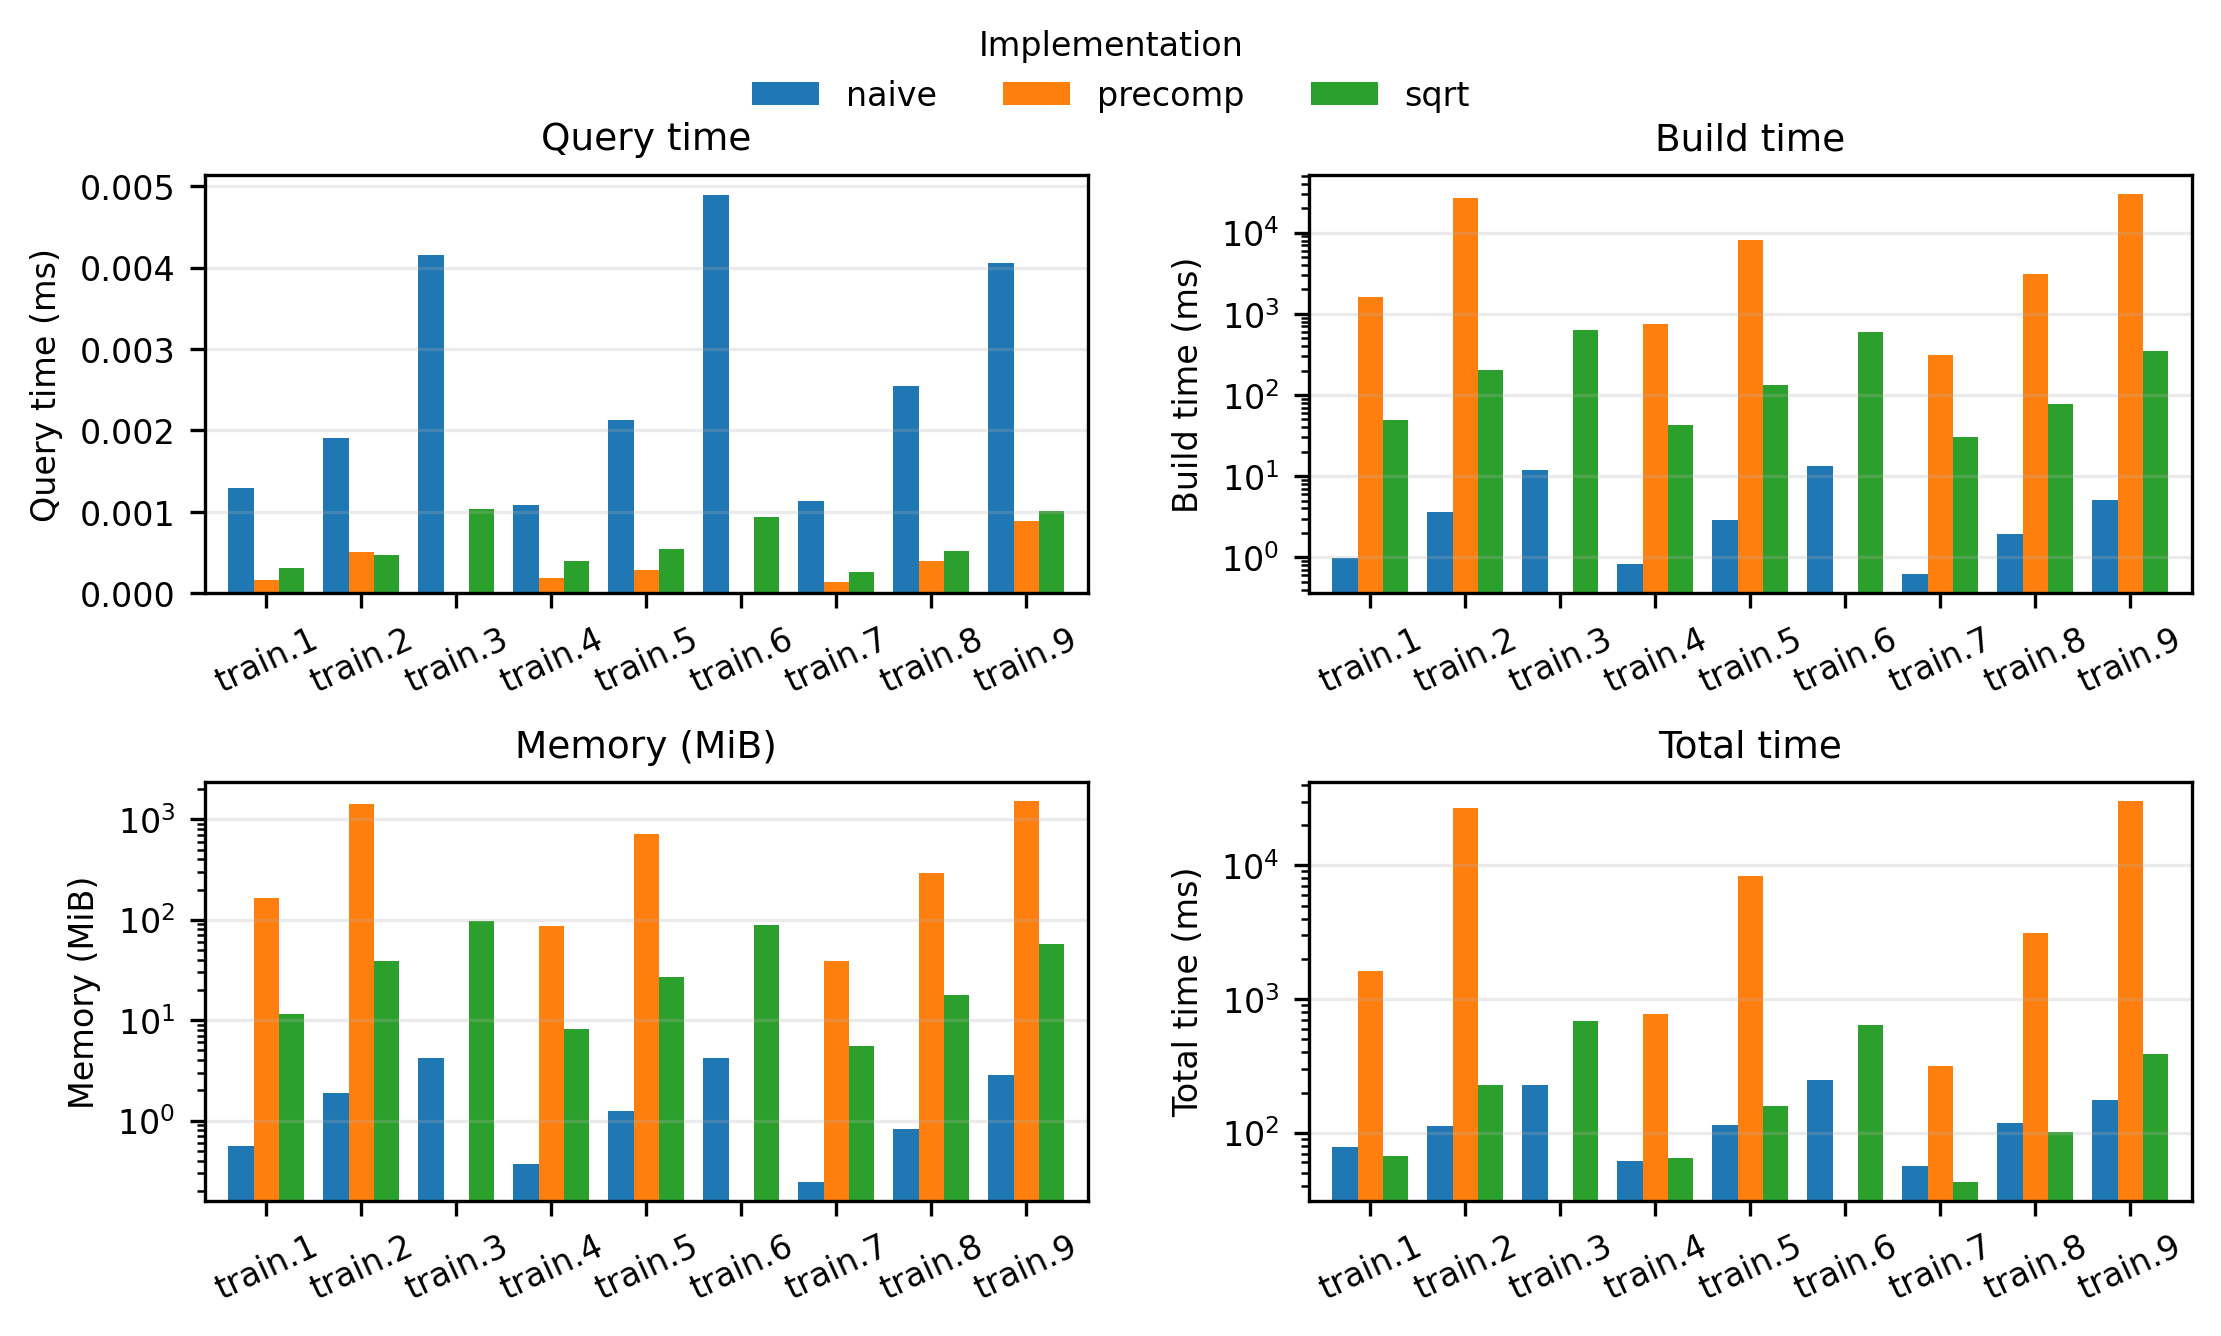

In [136]:
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
})

fig, axes = plt.subplots(2, 2, figsize=(7.2, 4.5), dpi=300)

metrics = [
    ("query_ms_per_query", "Query time (ms)", False),
    ("build_mean_ms", "Build time (ms)", True),
    ("memory_mib", "Memory (MiB)", True),
    ("total_mean_ms", "Total time (ms)", True),
]

for ax, (metric, ylabel, use_log) in zip(axes.flat, metrics):
    pivot = summary[:25].pivot(
        index="dataset",
        columns="impl",
        values=metric
    )

    pivot.plot(
        kind="bar",
        ax=ax,
        width=0.8
    )

    ax.set_title(ylabel.replace(" (ms)", "") if "ms" in ylabel else ylabel)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

    if use_log:
        ax.set_yscale("log")

    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Implementation",
    loc="upper center",
    ncol=min(len(labels), 4),
    frameon=False,
)

for ax in axes.flat:
    ax.legend().remove()

plt.subplots_adjust(
    left=0.07,
    right=0.99,
    bottom=0.12,
    top=0.88,
    wspace=0.25,
    hspace=0.45
)

plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_17396\1519369374.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


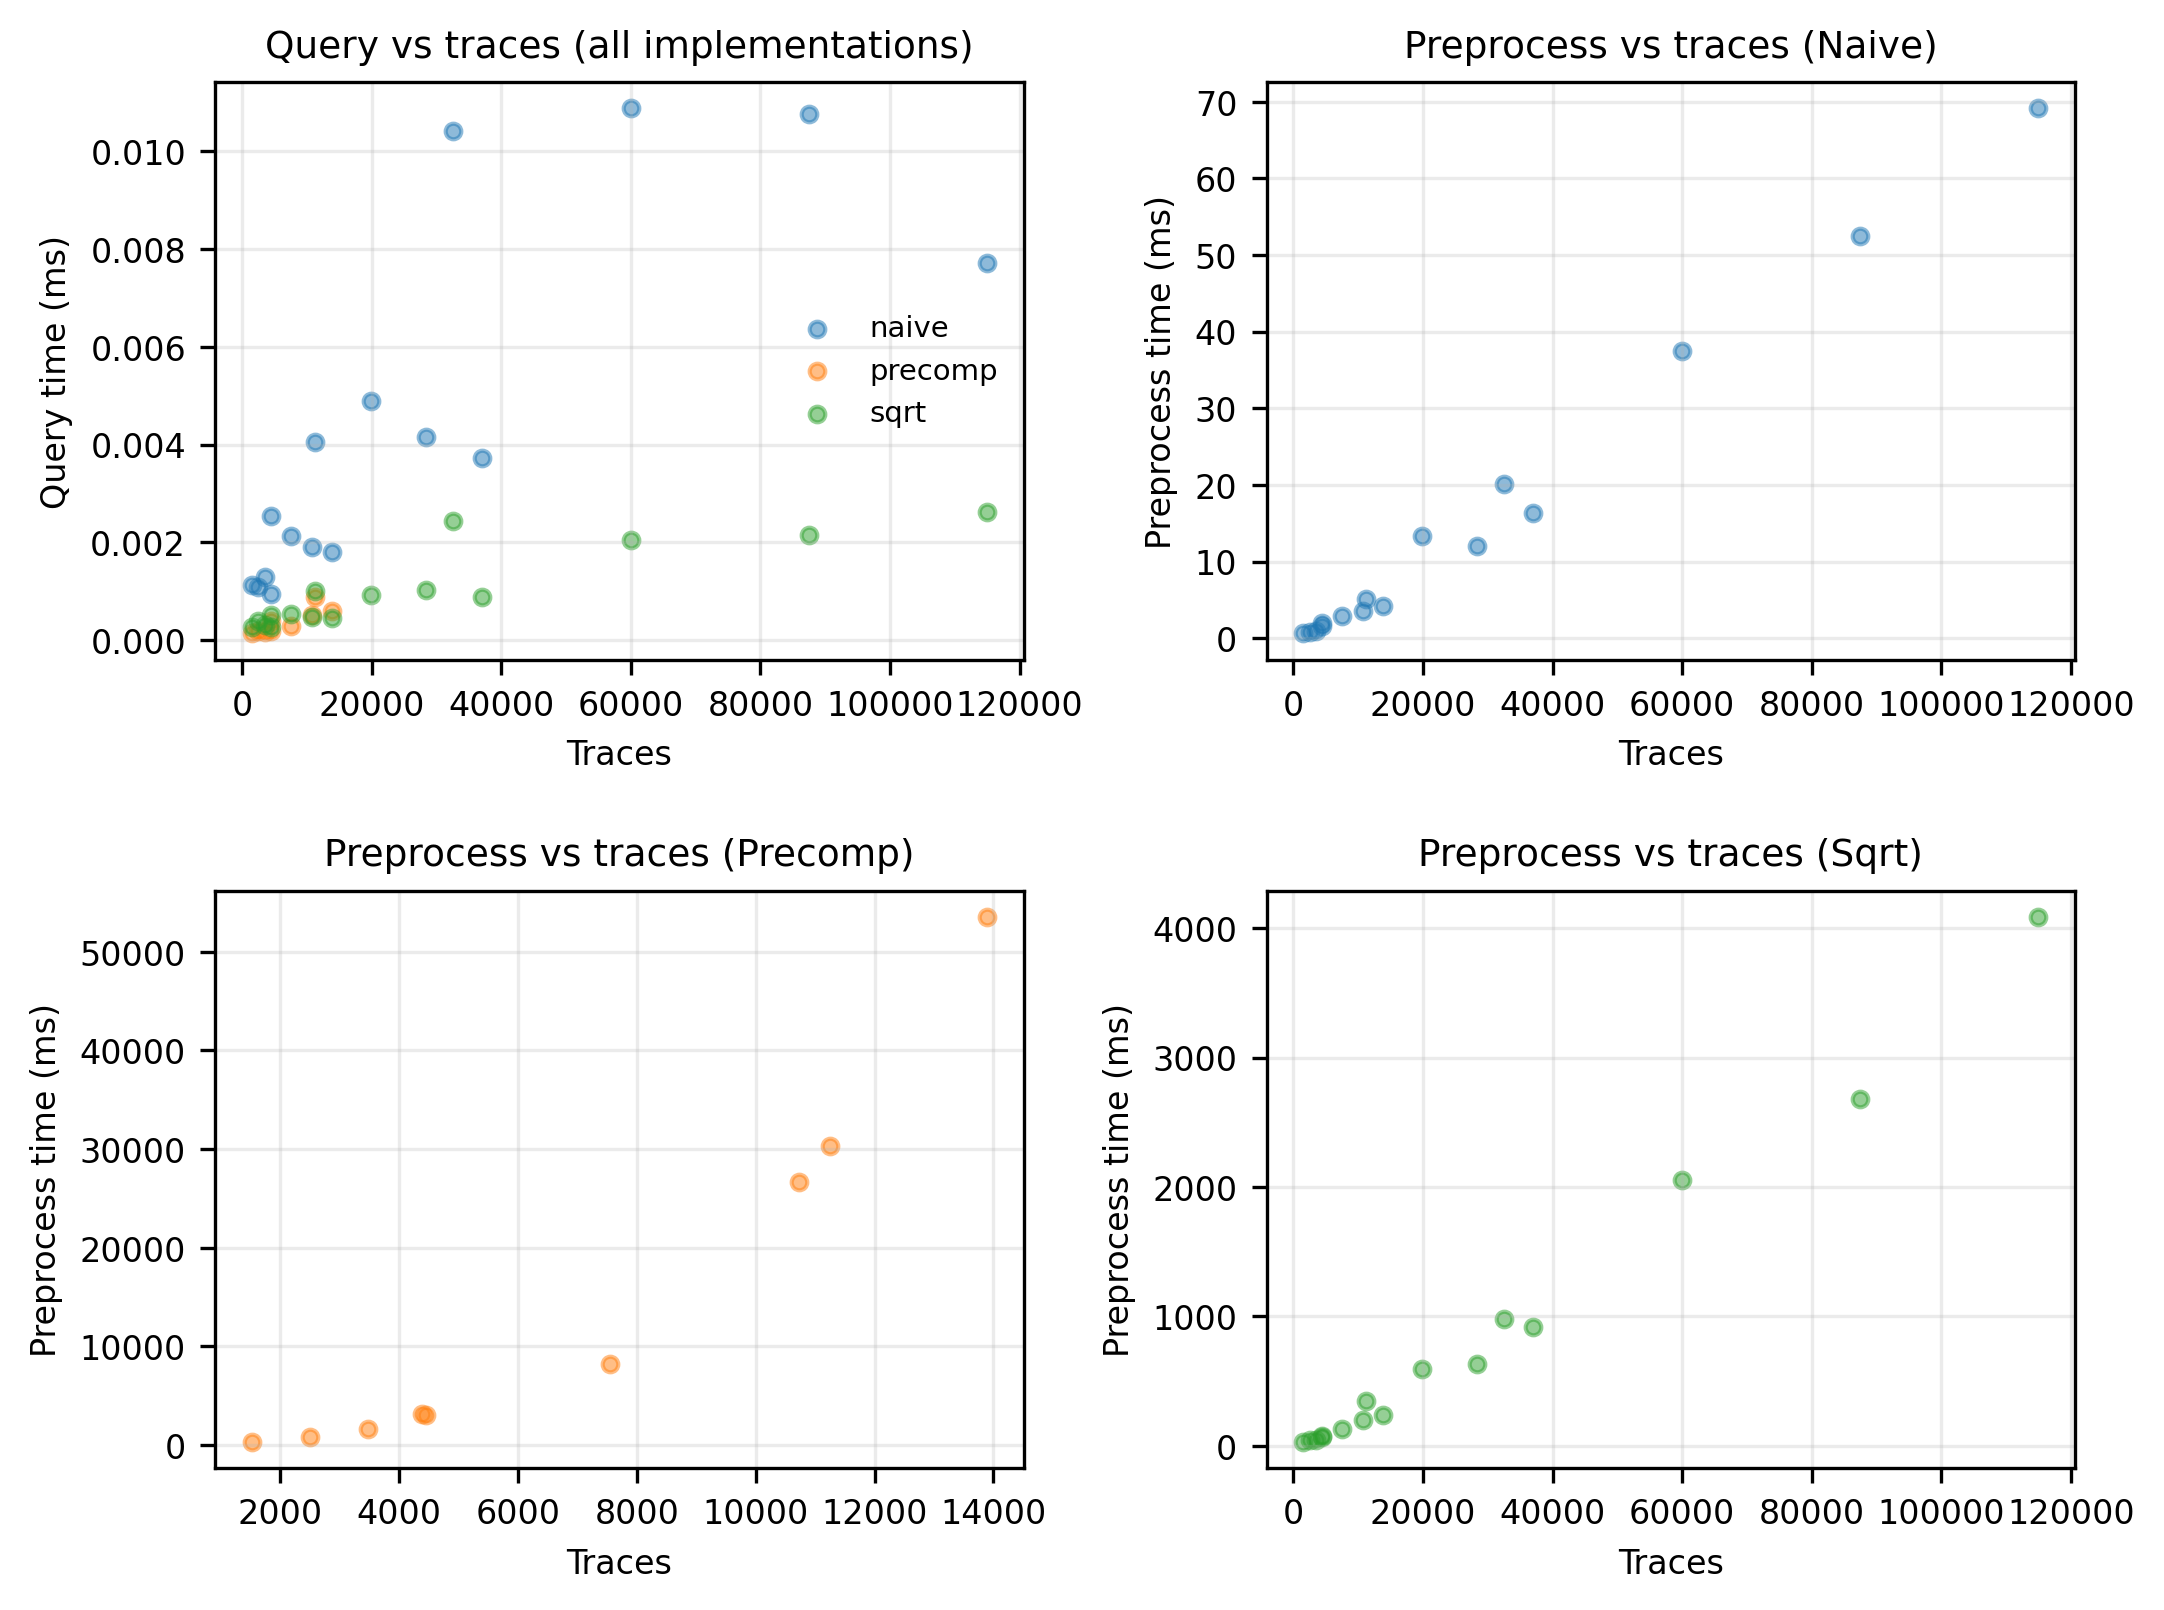

In [137]:
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
})

colors = {
    "naive": "tab:blue",
    "precomp": "tab:orange",
    "sqrt": "tab:green"
}


from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(8, 6), dpi=300)


gs = GridSpec(2, 2, figure=fig, wspace=0.3, hspace=0.4)


ax00 = fig.add_subplot(gs[0, 0])

for impl in ["naive", "precomp", "sqrt"]:
    sub = summary[summary["impl"] == impl].sort_values("num_traces")
    ax00.scatter(
        sub["num_traces"],
        sub["query_ms_per_query"],
        s=14,
        alpha=0.5,
        color=colors[impl],
        label=impl
    )

ax00.set_title("Query vs traces (all implementations)")
ax00.set_xlabel("Traces")
ax00.set_ylabel("Query time (ms)")
ax00.grid(alpha=0.25)
ax00.legend(frameon=False, fontsize=7)


ax01 = fig.add_subplot(gs[0, 1])

sub = summary[summary["impl"] == "naive"].sort_values("num_traces")
ax01.scatter(sub["num_traces"], sub["build_mean_ms"], s=14, alpha=0.5, color=colors["naive"])

ax01.set_title("Preprocess vs traces (Naive)")
ax01.set_xlabel("Traces")
ax01.set_ylabel("Preprocess time (ms)")
ax01.grid(alpha=0.25)

ax10 = fig.add_subplot(gs[1, 0])

sub = summary[summary["impl"] == "precomp"].sort_values("num_traces")
ax10.scatter(sub["num_traces"], sub["build_mean_ms"], s=14, alpha=0.5, color=colors["precomp"])

ax10.set_title("Preprocess vs traces (Precomp)")
ax10.set_xlabel("Traces")
ax10.set_ylabel("Preprocess time (ms)")
ax10.grid(alpha=0.25)

ax11 = fig.add_subplot(gs[1, 1])

sub = summary[summary["impl"] == "sqrt"].sort_values("num_traces")
ax11.scatter(sub["num_traces"], sub["build_mean_ms"], s=14, alpha=0.5, color=colors["sqrt"])

ax11.set_title("Preprocess vs traces (Sqrt)")
ax11.set_xlabel("Traces")
ax11.set_ylabel("Preprocess time (ms)")
ax11.grid(alpha=0.25)

plt.tight_layout()
plt.show()

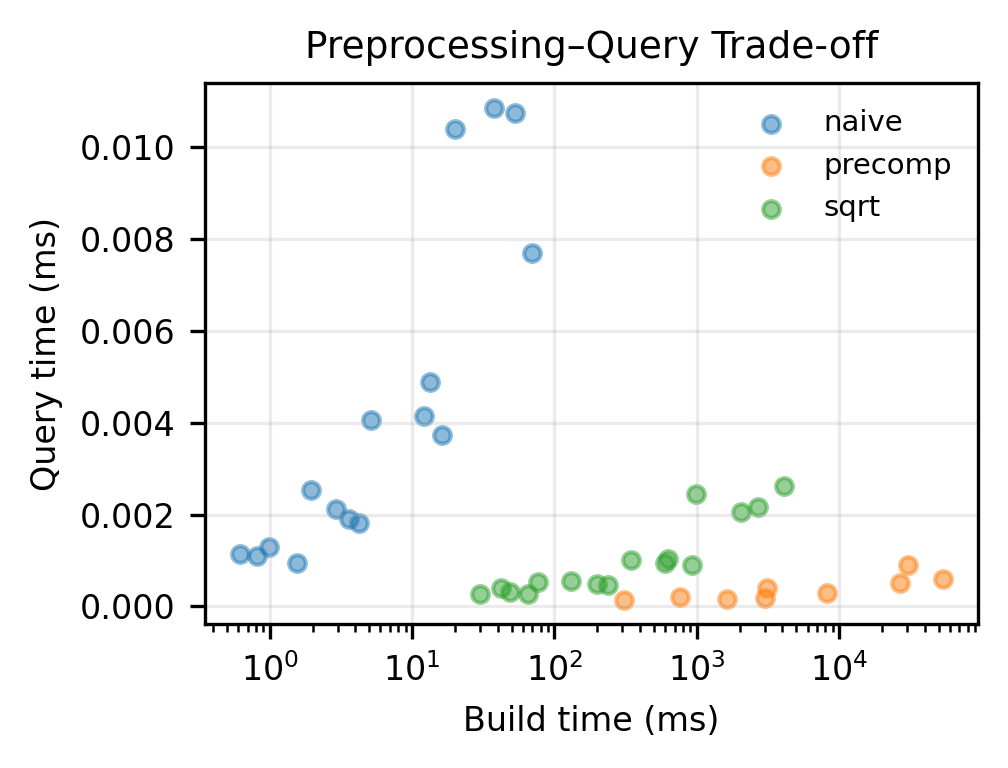

In [138]:
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
})

fig, ax = plt.subplots(figsize=(3.4, 2.6), dpi=300)

impls = summary["impl"].unique()

for impl in impls:
    sub = summary[summary["impl"] == impl]
    ax.scatter(
        sub["build_mean_ms"],
        sub["query_ms_per_query"],
        s=16,
        alpha=0.5,
        label=impl
    )

ax.set_title("Preprocessing–Query Trade-off")
ax.set_xlabel("Build time (ms)")
ax.set_ylabel("Query time (ms)")
ax.set_xscale("log")
ax.grid(alpha=0.25)

ax.legend(frameon=False, fontsize=7)

plt.tight_layout()
plt.show()